# V43 (Option C): LQ45 AI Strategy with Regime Lock (Cool-down Period)

**Objective**: Directly address the 'Whipsaw' problem by enforcing a **Regime Lock** period. Once a decision is made to switch regimes (Invested <-> Cash), the strategy is forced to hold that position for a minimum number of days.

### Modification (Regime Lock Logic):
We introduce a `cooldown` counter to prevent rapid-fire switching.

**New Logic:**
- **Regime Switch Condition**:
  - Evaluate the standard Hybrid Logic (AI < 0.60 AND Price < MA50).
  - IF a switch is triggered: **Lock the new state for 10 Days**.
  - During the lock period, ignore all new signals.

**Rationale**:
- This forces the strategy to commit to a decision, naturally filtering out high-frequency noise and significantly reducing transaction costs.

### Comparisons:
1. **AI Hybrid V43 (Regime Lock 10d)**.
2. **Markowitz Static (Baseline)**.
3. **IHSG Proxy (Benchmark)**.


In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data (LQ45) ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_price = (1 + market_return).cumprod() * 100

print(f"Data Loaded: {len(data)} rows")


Data Loaded: 712 rows


In [2]:
# --- 2. Feature Engineering & AI Model ---

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
ma5 = market_price.rolling(window=5).mean()
ma20 = market_price.rolling(window=20).mean()
ma50 = market_price.rolling(window=50).mean()

features['Dist_MA20'] = market_price / ma20
features['Dist_MA50'] = market_price / ma50

# Calculate Trend Signal (Standard MA50)
trend_bullish = (market_price > ma50).astype(int)

# TARGET: MA Slope Direction
target = (ma5.shift(-1) > ma5).astype(int)

features = features.dropna()
target = target.reindex(features.index).fillna(0)
trend_bullish = trend_bullish.reindex(features.index).fillna(0)

train_mask = (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

xgb_model = xgb.XGBClassifier(n_estimators=120, learning_rate=0.04, max_depth=6, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

opt_t = 0.60
print(f"[Strategy] Using Base Threshold: {opt_t:.2f} with Regime Lock (10 Days)")


[Strategy] Using Base Threshold: 0.60 with Regime Lock (10 Days)


In [3]:
# --- 3. Simulation Logic (V43 Regime Lock) ---

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    sigma += np.eye(len(sigma)) * 1e-4 
    try:
        res = minimize(lambda w: -(np.sum(w*mu)/(np.sqrt(np.dot(w.T, np.dot(sigma, w))) + 1e-6)), 
                       [1./len(mu)]*len(mu), method='SLSQP', 
                       bounds=tuple((0, 1) for _ in range(len(mu))), 
                       constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
        return dict(zip(selected_returns.columns, res.x)) if res.success else {}
    except:
        return {}

def run_simulation_lock(strategy_type, test_dates, returns, ai_probs=None, trend_signal=None, threshold=0.5, fee=0.0025, lock_days=10):
    val, history, dates = 100.0, [100.0], [test_dates[0]]
    prev_weights = {}
    static_weights = None
    state_history = []
    
    # Regime Lock Variables
    current_regime = "Neutral" 
    days_since_switch = 999  # Start unlocked
    locked_weights = {} # Store weights during lock
    
    for i, date in enumerate(test_dates[:-1]):
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-30:loc_idx]
        
        weights = {}

        if strategy_type == 'AI Hybrid V43 (Lock)':
            prob = ai_probs.loc[date]
            is_trend_up = trend_signal.loc[date] == 1
            
            # Check Lock Status
            if days_since_switch < lock_days:
                # LOCKED: Maintain previous regime
                weights = locked_weights
                days_since_switch += 1
            else:
                # UNLOCKED: Evaluate Signal
                is_risk_off = (prob < threshold) and (not is_trend_up)
                
                if is_risk_off:
                    new_regime = "Cash"
                    weights = {'CASH': 1.0}
                else:
                    new_regime = "Invested"
                    valid_assets = window_rets.dropna(axis=1, how='any').columns
                    weights = optimize_markowitz(window_rets[valid_assets])
                
                # Check for Switch
                if new_regime != current_regime:
                    current_regime = new_regime
                    days_since_switch = 0 # Activate Lock
                    locked_weights = weights # Save weights to hold
                else:
                    # Even if not switching regime, we might re-optimize if Invested
                    # But to be strict with 'Lock', we can choose to HOLD weights or RE-OPTIMIZE weights.
                    # Let's say we RE-OPTIMIZE daily if Invested and not locked, but HOLD if locked.
                    # Here we are NOT locked, so we update weights normally.
                    pass
                    
        elif strategy_type == 'Markowitz Static':
            if static_weights is None:
                valid_assets = window_rets.dropna(axis=1, how='any').columns
                static_weights = optimize_markowitz(window_rets[valid_assets])
            weights = static_weights
            current_regime = "Static"
        
        state_history.append(current_regime)
        
        # Transaction Costs
        all_assets = set(list(weights.keys()) + list(prev_weights.keys()))
        turnover = sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_assets)
        val -= (val * turnover * fee)
        
        next_date = test_dates[i+1]
        day_ret = 0 if 'CASH' in weights else sum(w * returns.loc[next_date, a] for a, w in weights.items())
        val *= (1 + day_ret)
        history.append(val); dates.append(next_date); prev_weights = weights
        
    return pd.DataFrame({'Portfolio_Value': history, 'State': state_history + [state_history[-1]]}, index=dates)


In [4]:
# --- 4. Models & Benchmark Execution ---
ai_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)
test_trend = trend_bullish.loc[X_test.index]

print("Running AI Hybrid V43 (Regime Lock 10d)...")
hybrid_res_lock = run_simulation_lock('AI Hybrid V43 (Lock)', X_test.index, returns, ai_probs, test_trend, threshold=opt_t, lock_days=10)

print("Running Markowitz Static...")
static_res = run_simulation_lock('Markowitz Static', X_test.index, returns)

print("Calculating IHSG Benchmark...")
ihsg_ret = market_return.loc[X_test.index]
ihsg_price = (1 + ihsg_ret).cumprod() * 100


Running AI Hybrid V43 (Regime Lock 10d)...
Running Markowitz Static...
Calculating IHSG Benchmark...


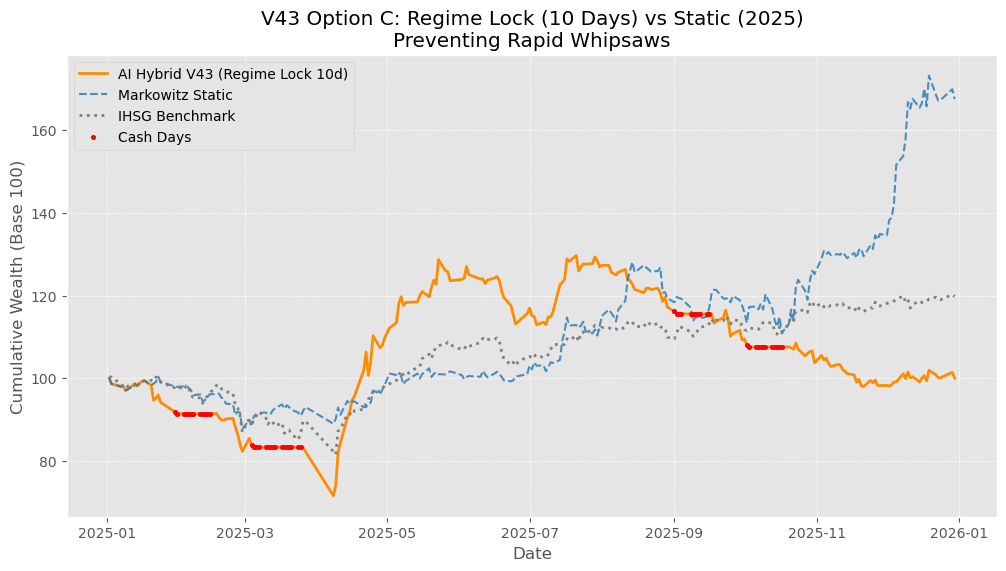

Total Regime Switches in V43 (Lock): 9


In [5]:
# --- Visualization: Performance Comparison ---
plt.figure(figsize=(12, 6))
plt.plot(hybrid_res_lock['Portfolio_Value'], label=f'AI Hybrid V43 (Regime Lock 10d)', color='darkorange', linewidth=2)
plt.plot(static_res['Portfolio_Value'], label='Markowitz Static', color='#1f77b4', linestyle='--', alpha=0.8)
plt.plot(ihsg_price, label='IHSG Benchmark', color='#7f7f7f', linestyle=':', linewidth=2)

# Highlight Regime Switches
regime_switches = hybrid_res_lock[hybrid_res_lock['State'].str.contains('Cash')]
plt.scatter(regime_switches.index, regime_switches['Portfolio_Value'], color='red', s=10, label='Cash Days', zorder=5)

plt.title(f'V43 Option C: Regime Lock (10 Days) vs Static (2025)\nPreventing Rapid Whipsaws')
plt.ylabel('Cumulative Wealth (Base 100)')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig('v43_regime_lock_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate switches count
switches_count = (hybrid_res_lock['State'] != hybrid_res_lock['State'].shift(1)).sum()
print(f"Total Regime Switches in V43 (Lock): {switches_count}")
